# ACI-Bench Evaluation — Out-of-Distribution Test

**Goal:** Evaluate the trained student models (Phi-3.5, Qwen2.5, Llama-3.2) against the
**ACI-bench test set** (40 real doctor-patient encounters with gold clinical notes).
This is an out-of-distribution test — none of these conversations were seen during training.

## What Needs to Be Done First (Manual Steps)

1. **Download the ACI-bench dataset** from:
   - GitHub: https://github.com/wyim/aci-bench (the `data/challenge_data/` folder)
   - Or Figshare: https://figshare.com/articles/dataset/aci-bench-corpus_zip/22494601
2. **Place the files** at `data/aci_bench/train.csv`, `data/aci_bench/valid.csv`, `data/aci_bench/test.csv`
3. **Set your `OPENAI_API_KEY`** in a `.env` file in the project root (only needed for LLM Judge)

## Pipeline
```
ACI-bench test.csv
    └─► parse_aci_sample()          # convert flat CSV → your internal format
            └─► ClinicalScribeInference.batch_inference()  # your existing inference_fixed.py
                    └─► _compute_metrics()                 # ROUGE + BERTScore (evaluator.py)
                            └─► LLMJudge.evaluate_batch()  # GPT-4o-mini judge (evaluator.py)
                                    └─► comparison table
```

## 1. Setup

In [1]:
import sys
import os

# Add project root to path so src.student.* imports work
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)  # All relative paths (./checkpoints, ./data) resolve from here
print(f"Working directory: {os.getcwd()}")

from dotenv import load_dotenv
load_dotenv()

# ── Model checkpoints to compare ───────────────────────────────────────────
MODELS = {
    "Phi-3.5 (FT+RAG)": {
        "model_path": "./checkpoints/phi35_clinical_scribe/hf_merged",
        "use_rag": True,
        "rag_overrides": {"use_reranker": True}
    },
    "Phi-3.5 (FT only)": {
        "model_path": "./checkpoints/phi35_clinical_scribe/hf_merged",
        "use_rag": False,
    },
    "Llama-3.2 3B (FT+RAG)": {
        "model_path": "./checkpoints/llama32_3b_clinical_scribe/hf_merged",
        "use_rag": True,
        "rag_overrides": {"use_reranker": True}
    },
    "Llama-3.2 3B (FT only)": {
        "model_path": "./checkpoints/llama32_3b_clinical_scribe/hf_merged",
        "use_rag": False,
    },
    "Llama-3.2 1B (FT+RAG)": {
        "model_path": "./checkpoints/llama32_1b_clinical_scribe/hf_merged",
        "use_rag": True,
        "rag_overrides": {"use_reranker": True}
    },
    "Llama-3.2 1B (FT only)": {
        "model_path": "./checkpoints/llama32_1b_clinical_scribe/hf_merged",
        "use_rag": False,
    },
}

# Official ACI-bench test set (40 samples, columns: dataset, encounter_id, dialogue, note)
ACI_TEST_CSV   = "./data/aci-bench-2023/aci-bench-corpus/challenge_data/clef_taskC_test3.csv"
OUTPUT_JSON    = "./data/aci-bench-2023/aci_eval_results.json"
MAX_SAMPLES    = None   # Set to e.g. 5 for a quick smoke-test; None = all 40
ENABLE_JUDGE   = True   # Set False to skip GPT-4o-mini judge (saves API cost)
ENABLE_BERTSCORE = True # Set False if bert-score is not installed

print("Configuration ready.")


Working directory: d:\ambient-scribe
Configuration ready.


## 2. ACI-Bench Data Loader

ACI-bench uses a flat CSV with columns: `dataset`, `encounter_id`, `dialogue`, `note`.

- `dialogue` is a flat string: `[doctor] hi , how are you ?[patient] i'm okay .`
- `note` is a free-text clinical note with section headings like `CHIEF COMPLAINT`, `HISTORY OF PRESENT ILLNESS`, etc.

The cells below convert these into the same format your `inference_fixed.py` expects.

In [4]:
import re
import csv
import json
from pathlib import Path
from typing import Dict, List, Optional


def parse_aci_dialogue(flat_str: str) -> List[Dict]:
    """
    Convert ACI-bench flat dialogue string to turn list.

    Input:  '[doctor] hi martha .[patient] i\'m doing okay .'
    Output: [{'speaker': 'Doctor', 'text': 'hi martha.', 'turn_number': 0}, ...]
    """
    # Split by [doctor] or [patient] markers — keep the delimiter
    parts = re.split(r'(\[doctor\]|\[patient\])', flat_str)
    turns = []
    for i in range(1, len(parts) - 1, 2):
        tag  = parts[i].strip()          # '[doctor]' or '[patient]'
        text = parts[i + 1].strip()      # actual text
        if not text:
            continue
        speaker = "Doctor" if tag == "[doctor]" else "Patient"
        turns.append({"speaker": speaker, "text": text, "turn_number": len(turns)})
    return turns


def parse_aci_note(note_str: str) -> Dict[str, str]:
    """
    Parse ACI-bench free-text note into a structured summary dict.

    ACI-bench section headings (not always present):
        CHIEF COMPLAINT / CC
        HISTORY OF PRESENT ILLNESS / HPI
        PAST HISTORY / MEDICAL HISTORY
        CURRENT MEDICATIONS / MEDICATIONS
        ALLERGIES
        SOCIAL HISTORY
        FAMILY HISTORY
        REVIEW OF SYSTEMS
        PHYSICAL EXAM / PHYSICAL EXAMINATION / VITALS
        ASSESSMENT AND PLAN / ASSESSMENT
        INSTRUCTIONS  (maps to safety_netting)
    """
    heading_map = [
        (r"CHIEF COMPLAINT|^CC:",                           "chief_complaint"),
        (r"HISTORY OF PRESENT ILLNESS|^HPI",               "history_of_present_illness"),
        (r"PAST HISTORY|MEDICAL HISTORY|PAST MEDICAL",     "past_medical_history"),
        (r"CURRENT MEDICATIONS|MEDICATIONS",               "medications"),
        (r"ALLERGIES",                                      "allergies"),
        (r"SOCIAL HISTORY",                                 "social_history"),
        (r"FAMILY HISTORY",                                 "family_history"),
        (r"REVIEW OF SYSTEMS",                              "review_of_systems"),
        (r"PHYSICAL EXAM(?:INATION)?|VITALS|RESULTS",      "physical_examination"),
        (r"ASSESSMENT AND PLAN|ASSESSMENT",                "assessment"),
        (r"INSTRUCTIONS?",                                  "safety_netting"),
    ]

    # Build a single split pattern from all headings
    heading_pattern = "|".join(f"(?:{h})" for h, _ in heading_map)
    full_pattern = rf"(?m)^({heading_pattern})\s*\n"

    parts = re.split(full_pattern, note_str, flags=re.MULTILINE)

    summary: Dict[str, str] = {}
    i = 1
    while i < len(parts) - 1:
        heading_text = parts[i].strip()
        content      = parts[i + 1].strip() if i + 1 < len(parts) else ""
        # Find the matching key
        for pattern, key in heading_map:
            if re.search(pattern, heading_text, re.IGNORECASE):
                # Avoid overwriting with a later match for the same key
                # (e.g. ASSESSMENT appearing before ASSESSMENT AND PLAN)
                if key not in summary:
                    summary[key] = content
                break
        i += 2

    # If the parser found nothing (some notes have no standard headings),
    # fall back to treating the whole note as the assessment.
    if not summary:
        summary["assessment"] = note_str.strip()

    return summary


def dialogue_turns_to_text(turns: List[Dict]) -> str:
    """Convert turn list to plain text (what inference_fixed.py _build_prompt expects)."""
    return "\n".join(f"{t['speaker']}: {t['text']}" for t in turns)


def summary_dict_to_text(summary: Dict[str, str]) -> str:
    """Convert structured summary dict to the same text format the model outputs."""
    field_map = [
        ("chief_complaint",           "Chief Complaint"),
        ("history_of_present_illness","History of Present Illness"),
        ("past_medical_history",      "Past Medical History"),
        ("medications",               "Medications"),
        ("allergies",                 "Allergies"),
        ("social_history",            "Social History"),
        ("family_history",            "Family History"),
        ("review_of_systems",         "Review of Systems"),
        ("physical_examination",      "Examination Findings"),
        ("assessment",                "Assessment"),
        ("safety_netting",            "Safety Netting"),
    ]
    lines = []
    for key, label in field_map:
        val = summary.get(key, "")
        if val and val.strip():
            lines.append(f"**{label}:** {val.strip()}")
    return "\n".join(lines)


def load_aci_bench(csv_path: str, max_samples: Optional[int] = None) -> List[Dict]:
    """
    Load ACI-bench CSV and return a list of samples in the project's internal format.

    Each sample has:
        id            : encounter_id (e.g. 'D2N001')
        dialogue_text : plain text 'Doctor: ...\nPatient: ...'
        reference     : gold note as structured text (same format the model outputs)
        raw_note      : original note string (for reference)
        dataset_tag   : 'virtassist', 'virtscribe', or 'aci'
    """
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(
            f"ACI-bench file not found: {csv_path}\n"
            "Download from https://github.com/wyim/aci-bench and place in data/aci_bench/"
        )

    samples = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            turns         = parse_aci_dialogue(row["dialogue"])
            dialogue_text = dialogue_turns_to_text(turns)
            summary_dict  = parse_aci_note(row["note"])
            reference     = summary_dict_to_text(summary_dict)

            samples.append({
                "id":           row["encounter_id"],
                "dialogue_text": dialogue_text,
                "reference":    reference,
                "raw_note":     row["note"],
                "dataset_tag":  row["dataset"],
                "num_turns":    len(turns),
            })

            if max_samples and len(samples) >= max_samples:
                break

    return samples


print("Data loader functions defined.")

Data loader functions defined.


In [5]:
# Load the ACI-bench test set
aci_samples = load_aci_bench(ACI_TEST_CSV, max_samples=MAX_SAMPLES)

dialogues  = [s["dialogue_text"] for s in aci_samples]
references = [s["reference"]     for s in aci_samples]

print(f"Loaded {len(aci_samples)} ACI-bench test samples")
print(f"Dataset breakdown: {{}}".format(
    {tag: sum(1 for s in aci_samples if s['dataset_tag'] == tag)
     for tag in set(s['dataset_tag'] for s in aci_samples)}
))
print(f"Avg turns per dialogue: {sum(s['num_turns'] for s in aci_samples) / len(aci_samples):.1f}")

# Sanity check — show first sample
print("\n--- First sample (encounter_id:", aci_samples[0]['id'], ") ---")
print("DIALOGUE (first 300 chars):\n", aci_samples[0]['dialogue_text'][:300])
print("\nREFERENCE NOTE (first 300 chars):\n", aci_samples[0]['reference'][:300])

Loaded 40 ACI-bench test samples
Dataset breakdown: {'virtscribe': 8, 'aci': 22, 'virtassist': 10}
Avg turns per dialogue: 57.5

--- First sample (encounter_id: D2N168 ) ---
DIALOGUE (first 300 chars):
 Doctor: hi diane , how are you ?
Patient: i'm doing okay , how are you ?
Doctor: i'm doin' okay . so i know the nurse told you about dax and i'd like to tell dax a little bit about you okay ?
Patient: okay .
Doctor: diane is a 28 year old female with a past medical history , significant for , depres

REFERENCE NOTE (first 300 chars):
 **Chief Complaint:** Emergency room follow-up.
**History of Present Illness:** Ms. Diane Baker is a 28-year-old female with a past medical history significant for depression, and hypertension, who presents for emergency room follow-up.

The patient went for a walk yesterday and began to feel lighthe


## 3. Run Inference — All Models

For each model in `MODELS`, we load it via `ClinicalScribeInference` (your existing `inference_fixed.py`)
and call `batch_inference()`. The model is unloaded from GPU after each run to avoid OOM.

> **Note:** Each model takes several minutes. If you only want to test one, edit the `MODELS` dict above.

In [6]:
import gc
import torch
import logging

logging.basicConfig(level=logging.WARNING)  # Suppress verbose Unsloth logs

from src.student.inference_fixed import ClinicalScribeInference, InferenceConfig

model_outputs: Dict[str, List[str]] = {}   # model_name → list of generated summaries
model_times:   Dict[str, List[float]] = {} # model_name → list of per-sample gen times

for model_name, cfg in MODELS.items():
    model_path = cfg["model_path"]
    use_rag    = cfg["use_rag"]

    # Skip if checkpoint does not exist
    if not Path(model_path).exists():
        print(f"[SKIP] {model_name}: checkpoint not found at {model_path}")
        model_outputs[model_name] = ["" for _ in aci_samples]
        model_times[model_name]   = [0.0 for _ in aci_samples]
        continue

    print(f"\n{'='*60}")
    print(f"Running: {model_name}")
    print(f"  Path : {model_path}")
    print(f"  RAG  : {use_rag}")
    print(f"{'='*60}")

    inference_cfg = InferenceConfig(
        model_path=model_path,
        use_rag=use_rag,
        temperature=0.3,
        max_tokens=2048,
        top_p=0.9,
        rag_persist_dir="./data/llama_index_chroma_db",
        rag_top_k=5,
        rag_max_context_chars=3000,
    )

    try:
        scribe  = ClinicalScribeInference(inference_cfg)
        results = scribe.batch_inference(dialogues, use_rag=use_rag)

        model_outputs[model_name] = [r.get("raw_output", "") for r in results]
        model_times[model_name]   = [r.get("generation_time", 0.0) for r in results]

        print(f"  Done — {len(results)} outputs, "
              f"avg {sum(model_times[model_name])/len(model_times[model_name]):.1f}s/sample")

    except Exception as e:
        print(f"  ERROR: {e}")
        model_outputs[model_name] = ["" for _ in aci_samples]
        model_times[model_name]   = [0.0 for _ in aci_samples]

    finally:
        # Free GPU memory before next model
        try:
            del scribe
        except NameError:
            pass
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

print("\nAll inference runs complete.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!



Running: Phi-3.5 (FT+RAG)
  Path : ./checkpoints/phi35_clinical_scribe/hf_merged
  RAG  : True
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Done — 40 outputs, avg 13.2s/sample

Running: Phi-3.5 (FT only)
  Path : ./checkpoints/phi35_clinical_scribe/hf_merged
  RAG  : False
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Done — 40 outputs, avg 13.0s/sample

Running: Llama-3.2 3B (FT+RAG)
  Path : ./checkpoints/llama32_3b_clinical_scribe/hf_merged
  RAG  : True
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Done — 40 outputs, avg 14.7s/sample

Running: Llama-3.2 3B (FT only)
  Path : ./checkpoints/llama32_3b_clinical_scribe/hf_merged
  RAG  : False
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Done — 40 outputs, avg 14.6s/sample

Running: Llama-3.2 1B (FT+RAG)
  Path : ./checkpoints/llama32_1b_clinical_scribe/hf_merged
  RAG  : True
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
  Done — 40 outputs, avg 7.5s/sample

Running: Llama-3.2 1B (FT only)
  Path : ./checkpoints/llama32_1b_clinical_scribe/hf_merged
  RAG  : False
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free lice

In [7]:

# ── Save inference results so they survive a kernel/environment switch ─────
# After this cell finishes, you can switch to the 'bertscore_env' kernel
# and run the reload cell at the top of Section 4 to continue.

import json
from pathlib import Path

INFERENCE_CACHE = "./data/aci-bench-2023/inference_cache.json"

_cache = {
    "model_outputs":  model_outputs,
    "model_times":    model_times,
    "aci_samples":    aci_samples,          # includes dialogue_text, reference, etc.
    "models_order":   list(MODELS.keys()),  # preserve display order
}

Path(INFERENCE_CACHE).parent.mkdir(parents=True, exist_ok=True)
with open(INFERENCE_CACHE, "w", encoding="utf-8") as _f:
    json.dump(_cache, _f, indent=2, default=str)

print(f"Inference cache saved → {INFERENCE_CACHE}")
print(f"Models cached: {list(model_outputs.keys())}")
print(f"Samples per model: {len(next(iter(model_outputs.values())))}")
print()
print("You can now switch the kernel to 'bertscore_env' and run from Section 4 onwards.")


Inference cache saved → ./data/aci-bench-2023/inference_cache.json
Models cached: ['Phi-3.5 (FT+RAG)', 'Phi-3.5 (FT only)', 'Llama-3.2 3B (FT+RAG)', 'Llama-3.2 3B (FT only)', 'Llama-3.2 1B (FT+RAG)', 'Llama-3.2 1B (FT only)']
Samples per model: 40

You can now switch the kernel to 'bertscore_env' and run from Section 4 onwards.


## 4. Compute ROUGE and BERTScore

Uses the same `_compute_metrics` logic from `src/student/evaluator.py`, but called
directly here so we can pass ACI-bench gold notes as references.

In [2]:

#Environment restore — run this first if you switched to bertscore_env ──
# Safe to run even if inference already ran in this kernel session.

import sys, os, json
from pathlib import Path
from typing import Dict, List, Optional

# Re-establish project root (handles both: fresh kernel in notebooks/ dir,
# or continuing session where os.chdir already moved us to the project root)
cwd = Path(os.getcwd())
if (cwd / "src").exists():
    PROJECT_ROOT = str(cwd)           # already at project root
else:
    PROJECT_ROOT = str(cwd.parent)    # we're inside notebooks/

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # not strictly needed for metrics cells

# Restore config defaults (used if kernel was restarted)
INFERENCE_CACHE  = "./data/aci-bench-2023/inference_cache.json"
OUTPUT_JSON      = "./data/aci-bench-2023/aci_eval_results.json"
ENABLE_BERTSCORE = True
ENABLE_JUDGE     = True   # set False to skip GPT-4o-mini judge

# ── Load outputs — in-memory if available, else reload from cache ───────────
try:
    _ = model_outputs
    assert isinstance(model_outputs, dict) and len(model_outputs) > 0
    print(f"In-memory inference results detected ({len(model_outputs)} models) — no reload needed.")
except (NameError, AssertionError):
    print(f"Loading inference cache from {INFERENCE_CACHE} ...")
    with open(INFERENCE_CACHE, encoding="utf-8") as _f:
        _cache = json.load(_f)

    model_outputs = _cache["model_outputs"]
    model_times   = _cache["model_times"]
    aci_samples   = _cache["aci_samples"]
    dialogues     = [s["dialogue_text"] for s in aci_samples]
    references    = [s["reference"]     for s in aci_samples]

    # Minimal MODELS dict — keys only (needed for table ordering in later cells)
    MODELS = {k: {} for k in _cache["models_order"]}

    print(f"Loaded: {len(model_outputs)} models, {len(aci_samples)} samples each")
    print(f"Working directory: {os.getcwd()}")
    print("Ready to compute metrics.")


Loading inference cache from ./data/aci-bench-2023/inference_cache.json ...
Loaded: 6 models, 40 samples each
Working directory: d:\ambient-scribe
Ready to compute metrics.


In [3]:
import re
import numpy as np
from rouge_score import rouge_scorer as rouge_lib
from typing import Dict, List, Optional

# ── Section patterns (same as plot_dissertation_v2.py) ─────────────────────
CLINICAL_SECTIONS = [
    ("chief_complaint",           "Chief Complaint"),
    ("history_of_present_illness","History of Present Illness"),
    ("past_medical_history",      "Past Medical History"),
    ("medications",               "Medications"),
    ("allergies",                 "Allergies"),
    ("physical_examination",      "Examination Findings"),
    ("assessment",                "Assessment"),
    ("safety_netting",            "Safety Netting"),
]

SECTION_PATTERNS = {
    "chief_complaint":            r"\*?\*?Chief Complaint\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:History|Past|Medications|Allergies|Examination|Physical|Assessment|Plan|Safety|$))",
    "history_of_present_illness": r"\*?\*?History of Present Illness\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:Past|Medications|Allergies|Examination|Physical|Assessment|Plan|Safety|$))",
    "past_medical_history":       r"\*?\*?Past Medical History\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:Medications|Allergies|Examination|Physical|Assessment|Plan|Safety|$))",
    "medications":                r"\*?\*?Medications\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:Allergies|Examination|Physical|Assessment|Plan|Safety|$))",
    "allergies":                  r"\*?\*?Allergies\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:Examination|Physical|Assessment|Plan|Safety|$))",
    "physical_examination":       r"\*?\*?(?:Examination Findings|Physical Examination)\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:Assessment|Plan|Safety|$))",
    "assessment":                 r"\*?\*?Assessment\*?\*?\s*:?\s*(.*?)(?=\*?\*?(?:Plan|Safety|$))",
    "safety_netting":             r"\*?\*?Safety Netting\*?\*?\s*:?\s*(.*?)$",
}


def _parse_sections(text: str) -> Dict[str, str]:
    sections = {}
    for key, pattern in SECTION_PATTERNS.items():
        m = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        if m:
            sections[key] = m.group(1).strip()
    return sections


def compute_rouge_scores(candidates: List[str], refs: List[str]) -> Dict:
    """ROUGE-1/2/L batch average."""
    scorer = rouge_lib.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    r1, r2, rl = [], [], []
    for ref, cand in zip(refs, candidates):
        if not ref.strip() or not cand.strip():
            continue
        s = scorer.score(ref, cand)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {
        "rouge1": float(np.mean(r1)) if r1 else 0.0,
        "rouge2": float(np.mean(r2)) if r2 else 0.0,
        "rougeL": float(np.mean(rl)) if rl else 0.0,
        "n":      len(r1),
    }


def compute_bleu4_scores(candidates: List[str], refs: List[str]) -> Dict:
    """BLEU-1..4 batch average using NLTK sentence_bleu with method1 smoothing."""
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    smooth = SmoothingFunction().method1
    b1, b2, b3, b4 = [], [], [], []
    for ref, cand in zip(refs, candidates):
        if not ref.strip() or not cand.strip():
            continue
        rt = ref.lower().split()
        ct = cand.lower().split()
        if len(rt) < 4 or len(ct) < 4:
            continue
        b1.append(sentence_bleu([rt], ct, weights=(1,0,0,0),          smoothing_function=smooth))
        b2.append(sentence_bleu([rt], ct, weights=(0.5,0.5,0,0),      smoothing_function=smooth))
        b3.append(sentence_bleu([rt], ct, weights=(0.33,0.33,0.33,0), smoothing_function=smooth))
        b4.append(sentence_bleu([rt], ct, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth))
    return {
        "bleu1": float(np.mean(b1)) if b1 else 0.0,
        "bleu2": float(np.mean(b2)) if b2 else 0.0,
        "bleu3": float(np.mean(b3)) if b3 else 0.0,
        "bleu4": float(np.mean(b4)) if b4 else 0.0,
        "n":     len(b4),
    }


def compute_bertscore_f1(candidates: List[str], refs: List[str]) -> Dict:
    """BERTScore F1 using roberta-large (stable, no deberta overflow)."""
    from bert_score import score as bert_score
    valid_pairs = [(c, r) for c, r in zip(candidates, refs) if c.strip() and r.strip()]
    if not valid_pairs:
        return {"f1": 0.0, "precision": 0.0, "recall": 0.0}
    cands_v, refs_v = zip(*valid_pairs)
    P, R, F1 = bert_score(list(cands_v), list(refs_v), model_type="roberta-large", verbose=False)
    return {
        "f1":        float(F1.mean()),
        "precision": float(P.mean()),
        "recall":    float(R.mean()),
    }


def compute_per_section_metrics(candidates: List[str], refs: List[str]) -> Dict:
    """Per-section ROUGE-1, ROUGE-L, BLEU-4, BERTScore-F1 (same approach as plot_dissertation_v2.py)."""
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    smooth = SmoothingFunction().method1
    scorer = rouge_lib.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

    buckets = {
        key: {"rouge1": [], "rougeL": [], "bleu4": [], "bs_refs": [], "bs_cands": []}
        for key, _ in CLINICAL_SECTIONS
    }

    for ref, cand in zip(refs, candidates):
        ref_secs  = _parse_sections(ref)
        cand_secs = _parse_sections(cand)
        for key, _ in CLINICAL_SECTIONS:
            r = ref_secs.get(key, "")
            c = cand_secs.get(key, "")
            if not r:          # skip if no reference section
                continue
            s = scorer.score(r, c)
            buckets[key]["rouge1"].append(s["rouge1"].fmeasure)
            buckets[key]["rougeL"].append(s["rougeL"].fmeasure)
            # BLEU-4
            rt, ct = r.lower().split(), c.lower().split()
            if len(rt) >= 4 and len(ct) >= 4:
                b4 = sentence_bleu([rt], ct, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)
            else:
                b4 = 0.0
            buckets[key]["bleu4"].append(b4)
            buckets[key]["bs_refs"].append(r)
            buckets[key]["bs_cands"].append(c)

    result = {}
    for key, label in CLINICAL_SECTIONS:
        bk = buckets[key]
        bs_f1 = 0.0
        if bk["bs_refs"]:
            try:
                bs = compute_bertscore_f1(bk["bs_cands"], bk["bs_refs"])
                bs_f1 = bs.get("f1", 0.0)
            except Exception:
                pass
        result[key] = {
            "label":  dict(CLINICAL_SECTIONS)[key],
            "n":      len(bk["rouge1"]),
            "rouge1": float(np.mean(bk["rouge1"])) if bk["rouge1"] else 0.0,
            "rougeL": float(np.mean(bk["rougeL"])) if bk["rougeL"] else 0.0,
            "bleu4":  float(np.mean(bk["bleu4"]))  if bk["bleu4"]  else 0.0,
            "bertscore": bs_f1,
        }
    return result


# ── Main computation loop ───────────────────────────────────────────────────
print("Computing ROUGE, BLEU-4, BERTScore, and per-section metrics for each model...")

auto_metrics:         Dict[str, Dict] = {}
per_section_metrics:  Dict[str, Dict] = {}

for model_name, candidates in model_outputs.items():
    print(f"\n  {model_name}")

    # Overall metrics
    rouge     = compute_rouge_scores(candidates, references)
    bleu      = compute_bleu4_scores(candidates, references)
    avg_time  = sum(model_times[model_name]) / max(len(model_times[model_name]), 1)
    empty     = sum(1 for c in candidates if not c.strip())

    print(f"    ROUGE-L={rouge['rougeL']:.3f}  BLEU-4={bleu['bleu4']:.3f}", end="", flush=True)

    bertscore = {}
    if ENABLE_BERTSCORE:
        try:
            bertscore = compute_bertscore_f1(candidates, references)
            print(f"  BERTScore-F1={bertscore['f1']:.3f}", end="")
        except Exception as e:
            print(f"  BERTScore error: {e}", end="")

    auto_metrics[model_name] = {
        "rouge":               rouge,
        "bleu":                bleu,
        "bertscore":           bertscore,
        "avg_generation_time_s": avg_time,
        "empty_outputs":       empty,
        "valid_outputs":       len(candidates) - empty,
    }

    # Per-section metrics
    print("  [sections]", end="", flush=True)
    try:
        per_section_metrics[model_name] = compute_per_section_metrics(candidates, references)
        print(" ✓")
    except Exception as e:
        print(f" ERROR: {e}")
        per_section_metrics[model_name] = {}

print("\nDone.")


Computing ROUGE, BLEU-4, BERTScore, and per-section metrics for each model...

  Phi-3.5 (FT+RAG)
    ROUGE-L=0.162  BLEU-4=0.036

c:\Users\943533\AppData\Local\miniconda3\envs\bertscore_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 10223.41it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

  BERTScore-F1=0.832  [sections]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9917.30it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9880.90it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status    

 ✓

  Phi-3.5 (FT only)
    ROUGE-L=0.162  BLEU-4=0.036

...

 ✓

  Llama-3.2 1B (FT only)
    ROUGE-L=0.198  BLEU-4=0.051

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8894.42it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  BERTScore-F1=0.845  [sections]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9245.10it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8829.64it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status    

 ✓

Done.


In [4]:

# ── Save auto_metrics + per_section_metrics so they survive switching back to ambient_311 ──
import json
from pathlib import Path

INFERENCE_CACHE = "./data/aci-bench-2023/inference_cache.json"

with open(INFERENCE_CACHE, encoding="utf-8") as _f:
    cache = json.load(_f)

cache["auto_metrics"]        = auto_metrics
cache["per_section_metrics"] = per_section_metrics

with open(INFERENCE_CACHE, "w", encoding="utf-8") as _f:
    json.dump(cache, _f, indent=2, default=str)

print(f"Saved to {INFERENCE_CACHE}")
print(f"Models with BERTScore: {sum(1 for v in auto_metrics.values() if v['bertscore'].get('f1', 0) > 0)} / {len(auto_metrics)}")
print(f"Models with BLEU-4:    {sum(1 for v in auto_metrics.values() if v['bleu'].get('bleu4', 0) > 0)} / {len(auto_metrics)}")
print(f"Per-section data:      {sum(1 for v in per_section_metrics.values() if v)} models")
print()
print("Switch kernel back to 'ambient_311' and run from Section 5 (LLM Judge) onwards.")


Saved to ./data/aci-bench-2023/inference_cache.json
Models with BERTScore: 6 / 6
Models with BLEU-4:    6 / 6
Per-section data:      6 models

Switch kernel back to 'ambient_311' and run from Section 5 (LLM Judge) onwards.


## 5. LLM-as-a-Judge (GPT-4o-mini)

> ** Environment switch required**: Switch the kernel back to **`ambient_311`** before running this section.
> `bertscore_env` is missing `pydantic` / full project deps, so `src.student.evaluator` cannot be imported there.
> After switching, run the restore cell below first — it reloads `model_outputs` and `auto_metrics` from the cache file.

Reuses `LLMJudge` from `src/student/evaluator.py` — the exact same rubric and prompts
used in your existing evaluation pipeline.

Judge dimensions: Clinical Accuracy, Completeness, Hallucination, Clinical Safety, Coherence, Conciseness (each 1–5).

Set `ENABLE_JUDGE = False` in the restore cell to skip.


In [1]:

# ── Restore for ambient_311 kernel — run this first after switching back ───
import sys, os, json
from pathlib import Path
from typing import Dict, List, Optional

_cwd = Path(os.getcwd())
PROJECT_ROOT = str(_cwd) if (_cwd / "src").exists() else str(_cwd.parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

INFERENCE_CACHE = "./data/aci-bench-2023/inference_cache.json"
OUTPUT_JSON     = "./data/aci-bench-2023/aci_eval_results.json"
ENABLE_JUDGE    = True   # set False to skip LLM judge

_need_reload = False
try:
    assert isinstance(model_outputs, dict)     and len(model_outputs) > 0
    assert isinstance(auto_metrics, dict)      and len(auto_metrics) > 0
    assert isinstance(per_section_metrics, dict)
    print(f"In-memory results detected — no reload needed ({len(model_outputs)} models).")
except (NameError, AssertionError):
    _need_reload = True

if _need_reload:
    print(f"Reloading from {INFERENCE_CACHE} ...")
    with open(INFERENCE_CACHE, encoding="utf-8") as _f:
        _cache = json.load(_f)

    model_outputs       = _cache["model_outputs"]
    model_times         = _cache["model_times"]
    aci_samples         = _cache["aci_samples"]
    auto_metrics        = _cache.get("auto_metrics", {})
    per_section_metrics = _cache.get("per_section_metrics", {})
    dialogues           = [s["dialogue_text"] for s in aci_samples]
    references          = [s["reference"]     for s in aci_samples]
    MODELS              = {k: {} for k in _cache["models_order"]}

    bs_ok   = sum(1 for v in auto_metrics.values() if v.get("bertscore", {}).get("f1", 0) > 0)
    bleu_ok = sum(1 for v in auto_metrics.values() if v.get("bleu", {}).get("bleu4", 0) > 0)
    sec_ok  = sum(1 for v in per_section_metrics.values() if v)
    print(f"Loaded: {len(model_outputs)} models, {len(aci_samples)} samples")
    print(f"BERTScore populated: {bs_ok}/{len(auto_metrics)} models")
    print(f"BLEU-4 populated:    {bleu_ok}/{len(auto_metrics)} models")
    print(f"Per-section data:    {sec_ok}/{len(per_section_metrics)} models")
    if bs_ok == 0:
        print("WARNING: BERTScore is empty — re-run the ROUGE/BERTScore cell in bertscore_env first.")
    print(f"Working directory: {os.getcwd()}")


Reloading from ./data/aci-bench-2023/inference_cache.json ...
Loaded: 6 models, 40 samples
BERTScore populated: 6/6 models
BLEU-4 populated:    6/6 models
Per-section data:    6/6 models
Working directory: d:\ambient-scribe


In [2]:
judge_metrics: Dict[str, Dict] = {}

if ENABLE_JUDGE:
    from src.student.evaluator import LLMJudge

    judge = LLMJudge(model="gpt-4o-mini", provider="openai")

    for model_name, candidates in model_outputs.items():
        print(f"\nJudging: {model_name}")

        scores_list = judge.evaluate_batch(dialogues, references, candidates)

        # Aggregate across samples (same logic as evaluator._aggregate_judge_scores)
        keys = ["clinical_accuracy", "completeness", "hallucination",
                "clinical_safety", "coherence", "conciseness", "overall"]
        agg = {}
        for k in keys:
            vals = [s[k] for s in scores_list if k in s and not s.get("judge_error")]
            agg[f"avg_{k}"] = sum(vals) / len(vals) if vals else 0

        critical = [err for s in scores_list for err in s.get("critical_errors", [])]
        agg["total_critical_errors"]       = len(critical)
        agg["samples_with_critical_errors"] = sum(
            1 for s in scores_list if s.get("critical_errors")
        )

        judge_metrics[model_name] = {"aggregated": agg, "per_sample": scores_list}
        print(f"  Overall: {agg['avg_overall']:.2f}/5  "
              f"Accuracy: {agg['avg_clinical_accuracy']:.2f}  "
              f"Safety: {agg['avg_clinical_safety']:.2f}  "
              f"Hallucination: {agg['avg_hallucination']:.2f}")
else:
    print("LLM judge disabled (ENABLE_JUDGE=False). Skipped.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


INFO:src.student.evaluator:  Judging 1/40...



Judging: Phi-3.5 (FT+RAG)


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 2/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 3/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 4/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 5/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 6/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 7/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 8/40...
INFO:httpx:HTTP Request: POST https://api.openai

  Overall: 3.25/5  Accuracy: 3.05  Safety: 3.62  Hallucination: 2.98

Judging: Phi-3.5 (FT only)


...

  Overall: 3.98/5  Accuracy: 3.67  Safety: 4.47  Hallucination: 3.20

Judging: Llama-3.2 1B (FT+RAG)


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 2/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 3/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 4/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 5/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 6/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 7/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 8/40...
INFO:httpx:HTTP Request: POST https://api.openai

  Overall: 3.41/5  Accuracy: 2.88  Safety: 3.67  Hallucination: 2.38

Judging: Llama-3.2 1B (FT only)


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 2/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 3/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 4/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 5/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 6/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 7/40...
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.student.evaluator:  Judging 8/40...
INFO:httpx:HTTP Request: POST https://api.openai

  Overall: 3.41/5  Accuracy: 2.85  Safety: 3.65  Hallucination: 2.27


## 6. Comparison Table

In [3]:
import pandas as pd

rows = []
for model_name in MODELS:
    if model_name not in auto_metrics:
        continue
    am = auto_metrics[model_name]
    jm = judge_metrics.get(model_name, {}).get("aggregated", {})

    row = {
        "Model":            model_name,
        "ROUGE-1":          round(am["rouge"].get("rouge1", 0), 3),
        "ROUGE-2":          round(am["rouge"].get("rouge2", 0), 3),
        "ROUGE-L":          round(am["rouge"].get("rougeL", 0), 3),
        "BLEU-4":           round(am.get("bleu", {}).get("bleu4", float("nan")), 3),
        "BERTScore F1":     round(am["bertscore"].get("f1", float("nan")), 3),
        "Avg Gen Time (s)": round(am["avg_generation_time_s"], 1),
        "Empty Outputs":    am["empty_outputs"],
    }

    if jm:
        row.update({
            "Judge Overall":       round(jm.get("avg_overall", 0), 2),
            "Judge Accuracy":      round(jm.get("avg_clinical_accuracy", 0), 2),
            "Judge Completeness":  round(jm.get("avg_completeness", 0), 2),
            "Judge Hallucination": round(jm.get("avg_hallucination", 0), 2),
            "Judge Safety":        round(jm.get("avg_clinical_safety", 0), 2),
            "Critical Errors":     jm.get("total_critical_errors", 0),
        })

    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")
print("ACI-Bench Evaluation Results — Out-of-Distribution Test")
print("=" * 70)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
display(df)


ACI-Bench Evaluation Results — Out-of-Distribution Test


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU-4,BERTScore F1,Avg Gen Time (s),Empty Outputs,Judge Overall,Judge Accuracy,Judge Completeness,Judge Hallucination,Judge Safety,Critical Errors
Model,,,,,,,,,,,,,
Phi-3.5 (FT+RAG),0.301,0.114,0.162,0.036,0.832,13.2,0,3.25,3.05,3.10,2.98,3.62,27
Phi-3.5 (FT only),0.297,0.111,0.162,0.036,0.833,13.0,0,3.22,2.95,3.02,2.88,3.60,30
Llama-3.2 3B (FT+RAG),0.441,0.151,0.216,0.060,0.852,14.7,0,3.98,3.73,4.00,3.20,4.35,13
Llama-3.2 3B (FT only),0.442,0.153,0.214,0.061,0.852,14.6,0,3.98,3.67,3.95,3.20,4.47,14
Llama-3.2 1B (FT+RAG),0.400,0.131,0.192,0.048,0.844,7.5,0,3.41,2.88,3.52,2.38,3.67,49
Llama-3.2 1B (FT only),0.413,0.136,0.198,0.051,0.845,7.4,0,3.41,2.85,3.48,2.27,3.65,55


In [4]:

# ── Per-Section Metrics Table ───────────────────────────────────────────────
# For each model: ROUGE-1, ROUGE-L, BLEU-4, BERTScore-F1 broken down by
# clinical note section (Chief Complaint, HPI, Assessment, etc.)

import pandas as pd

SECTION_LABELS = [
    ("chief_complaint",           "Chief Complaint"),
    ("history_of_present_illness","HPI"),
    ("past_medical_history",      "Past Medical Hx"),
    ("medications",               "Medications"),
    ("allergies",                 "Allergies"),
    ("physical_examination",      "Examination"),
    ("assessment",                "Assessment"),
    ("safety_netting",            "Safety Netting"),
]

for metric_key, metric_label in [
    ("rouge1",    "ROUGE-1"),
    ("rougeL",    "ROUGE-L"),
    ("bleu4",     "BLEU-4"),
    ("bertscore", "BERTScore-F1"),
]:
    rows_sec = []
    model_names_with_sec = [m for m in MODELS if m in per_section_metrics and per_section_metrics[m]]
    for section_key, section_label in SECTION_LABELS:
        row = {"Section": section_label}
        for model_name in model_names_with_sec:
            sec = per_section_metrics[model_name].get(section_key, {})
            val = sec.get(metric_key, float("nan"))
            row[model_name] = round(val, 3) if isinstance(val, float) else val
        rows_sec.append(row)

    df_sec = pd.DataFrame(rows_sec).set_index("Section")
    print(f"\nPer-Section {metric_label}")
    print("─" * 70)
    display(df_sec)



Per-Section ROUGE-1
──────────────────────────────────────────────────────────────────────


,Phi-3.5 (FT+RAG),Phi-3.5 (FT only),Llama-3.2 3B (FT+RAG),Llama-3.2 3B (FT only),Llama-3.2 1B (FT+RAG),Llama-3.2 1B (FT only)
Section,,,,,,
Chief Complaint,0.325,0.335,0.293,0.323,0.302,0.304
HPI,0.262,0.252,0.320,0.294,0.281,0.313
Past Medical Hx,0.102,0.115,0.242,0.232,0.194,0.198
Medications,0.163,0.143,0.221,0.172,0.167,0.185
Allergies,0.114,0.108,0.168,0.108,0.117,0.072
Examination,0.192,0.185,0.293,0.294,0.252,0.240
Assessment,0.129,0.104,0.203,0.214,0.168,0.192
Safety Netting,0.047,0.046,0.122,0.121,0.120,0.117



Per-Section ROUGE-L
──────────────────────────────────────────────────────────────────────


,Phi-3.5 (FT+RAG),Phi-3.5 (FT only),Llama-3.2 3B (FT+RAG),Llama-3.2 3B (FT only),Llama-3.2 1B (FT+RAG),Llama-3.2 1B (FT only)
Section,,,,,,
Chief Complaint,0.312,0.321,0.286,0.317,0.293,0.294
HPI,0.208,0.200,0.222,0.206,0.208,0.223
Past Medical Hx,0.096,0.103,0.213,0.207,0.187,0.188
Medications,0.149,0.134,0.177,0.155,0.155,0.176
Allergies,0.093,0.084,0.141,0.094,0.108,0.062
Examination,0.143,0.150,0.219,0.219,0.179,0.172
Assessment,0.123,0.100,0.184,0.199,0.132,0.175
Safety Netting,0.032,0.036,0.085,0.085,0.083,0.089



Per-Section BLEU-4
──────────────────────────────────────────────────────────────────────


,Phi-3.5 (FT+RAG),Phi-3.5 (FT only),Llama-3.2 3B (FT+RAG),Llama-3.2 3B (FT only),Llama-3.2 1B (FT+RAG),Llama-3.2 1B (FT only)
Section,,,,,,
Chief Complaint,0.080,0.083,0.057,0.078,0.062,0.060
HPI,0.038,0.024,0.021,0.020,0.022,0.022
Past Medical Hx,0.010,0.019,0.021,0.029,0.015,0.014
Medications,0.079,0.079,0.018,0.022,0.024,0.067
Allergies,0.006,0.005,0.016,0.007,0.011,0.006
Examination,0.030,0.035,0.059,0.065,0.038,0.042
Assessment,0.029,0.017,0.032,0.032,0.012,0.039
Safety Netting,0.003,0.002,0.006,0.006,0.006,0.006



Per-Section BERTScore-F1
──────────────────────────────────────────────────────────────────────


,Phi-3.5 (FT+RAG),Phi-3.5 (FT only),Llama-3.2 3B (FT+RAG),Llama-3.2 3B (FT only),Llama-3.2 1B (FT+RAG),Llama-3.2 1B (FT only)
Section,,,,,,
Chief Complaint,0.925,0.928,0.912,0.916,0.914,0.915
HPI,0.874,0.872,0.871,0.868,0.864,0.865
Past Medical Hx,0.854,0.863,0.874,0.871,0.865,0.866
Medications,0.879,0.869,0.871,0.867,0.858,0.857
Allergies,0.843,0.839,0.841,0.831,0.834,0.828
Examination,0.861,0.862,0.862,0.864,0.862,0.858
Assessment,0.873,0.865,0.861,0.864,0.853,0.857
Safety Netting,0.840,0.841,0.831,0.832,0.833,0.833


## 7. Per-Model Visualisation

C:\Users\943533\AppData\Local\Temp\ipykernel_46812\3460521927.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=15, ha="right", fontsize=9)


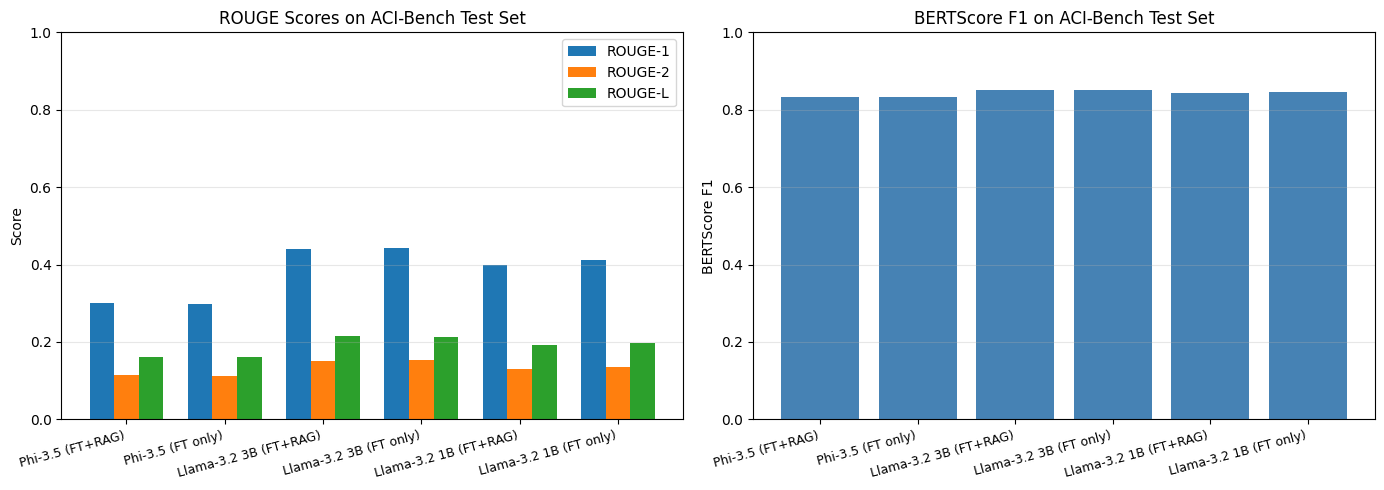

Saved: data/aci_bench/aci_rouge_bertscore.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

model_names = [m for m in MODELS if m in auto_metrics]

#  ROUGE bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROUGE
metrics_rouge = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
x = np.arange(len(model_names))
width = 0.25

for i, metric in enumerate(metrics_rouge):
    vals = [df.loc[m, metric] if m in df.index else 0 for m in model_names]
    axes[0].bar(x + i * width, vals, width, label=metric)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(model_names, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("Score")
axes[0].set_title("ROUGE Scores on ACI-Bench Test Set")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

# Right: BERTScore F1
bertscore_vals = [
    auto_metrics[m]["bertscore"].get("f1", 0) if m in auto_metrics else 0
    for m in model_names
]
axes[1].bar(model_names, bertscore_vals, color="steelblue")
axes[1].set_xticklabels(model_names, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("BERTScore F1")
axes[1].set_title("BERTScore F1 on ACI-Bench Test Set")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
Path("./data/aci_bench").mkdir(parents=True, exist_ok=True)
plt.savefig("./data/aci_bench/aci_rouge_bertscore.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/aci_bench/aci_rouge_bertscore.png")

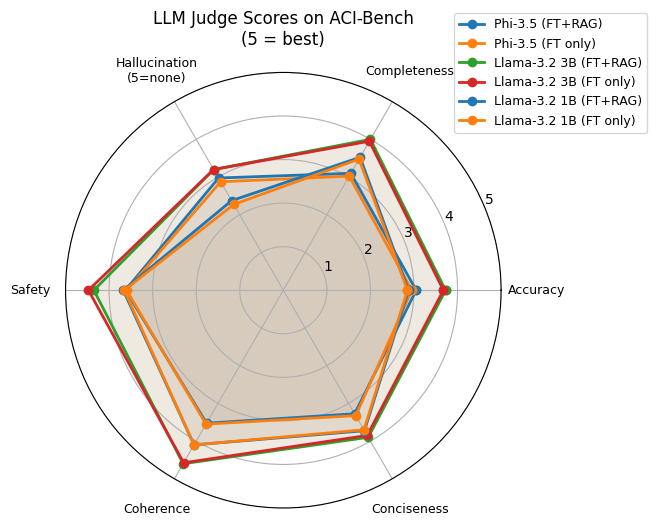

Saved: data/aci_bench/aci_judge_radar.png


In [ ]:
# ── Judge radar chart (only if judge was run) ──────────────────────────────
if judge_metrics:
    judge_dims = [
        "avg_clinical_accuracy", "avg_completeness", "avg_hallucination",
        "avg_clinical_safety", "avg_coherence", "avg_conciseness",
    ]
    dim_labels = [
        "Accuracy", "Completeness", "Hallucination\n(5=none)",
        "Safety", "Coherence", "Conciseness",
    ]

    N = len(judge_dims)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the polygon

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    for idx, model_name in enumerate(model_names):
        agg = judge_metrics.get(model_name, {}).get("aggregated", {})
        if not agg:
            continue
        vals = [agg.get(d, 0) for d in judge_dims]
        vals += vals[:1]
        ax.plot(angles, vals, "o-", linewidth=2, label=model_name,
                color=colors[idx % len(colors)])
        ax.fill(angles, vals, alpha=0.07, color=colors[idx % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dim_labels, fontsize=9)
    
    
    ax.tick_params(axis="x", pad=15)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_title("LLM Judge Scores on ACI-Bench\n(5 = best)", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax.grid(True)

    plt.tight_layout()
    Path("./data/aci_bench").mkdir(parents=True, exist_ok=True)
    plt.savefig("./data/aci_bench/aci_judge_radar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: data/aci_bench/aci_judge_radar.png")
else:
    print("Judge metrics not available — skipping radar chart.")

## 8. Qualitative Inspection

Pick a sample and compare what each model outputs vs the gold note.

In [13]:
SAMPLE_IDX = 0  # Change this to inspect different samples

sample = aci_samples[SAMPLE_IDX]
print(f"Encounter ID : {sample['id']}")
print(f"Dataset tag  : {sample['dataset_tag']}")
print(f"Turns        : {sample['num_turns']}")
print()
print("=" * 60)
print("DIALOGUE (first 600 chars):")
print("=" * 60)
print(sample["dialogue_text"][:600])

print()
print("=" * 60)
print("GOLD NOTE (ACI-bench):")
print("=" * 60)
print(sample["reference"])

for model_name in model_names:
    print()
    print("=" * 60)
    print(f"MODEL OUTPUT — {model_name}:")
    print("=" * 60)
    out = model_outputs.get(model_name, [""])[SAMPLE_IDX]
    print(out if out.strip() else "[empty output]")

Encounter ID : D2N168
Dataset tag  : virtassist
Turns        : 54

DIALOGUE (first 600 chars):
Doctor: hi diane , how are you ?
Patient: i'm doing okay , how are you ?
Doctor: i'm doin' okay . so i know the nurse told you about dax and i'd like to tell dax a little bit about you okay ?
Patient: okay .
Doctor: diane is a 28 year old female with a past medical history , significant for , depression and hypertension who presents for emergency room follow-up .
Doctor: so diane what's going on ? i heard that your- your blood pressure was really high in the emergency room . what happened ?
Patient: yeah , so i ended up going for a walk , um , yesterday 'cause it was sunny and it was really gr

GOLD NOTE (ACI-bench):
**Chief Complaint:** Emergency room follow-up.
**History of Present Illness:** Ms. Diane Baker is a 28-year-old female with a past medical history significant for depression, and hypertension, who presents for emergency room follow-up.

The patient went for a walk yesterday and b

## 9. Save Results to JSON

In [14]:
import json
from datetime import datetime

output = {
    "timestamp":       datetime.now().isoformat(),
    "num_aci_samples": len(aci_samples),
    "models_evaluated": list(MODELS.keys()),
    "auto_metrics":    auto_metrics,
    "judge_metrics":   {
        k: v["aggregated"] for k, v in judge_metrics.items()
    },
    # Uncomment to also save raw per-sample outputs (increases file size)
    # "raw_outputs":  model_outputs,
    # "per_sample_judge": {k: v["per_sample"] for k, v in judge_metrics.items()},
}

out_path = Path(OUTPUT_JSON)
out_path.parent.mkdir(parents=True, exist_ok=True)

with open(out_path, "w") as f:
    json.dump(output, f, indent=2, default=str)

print(f"Results saved to {out_path}")

Results saved to data\aci-bench-2023\aci_eval_results.json


## Appendix — How to Interpret ACI-Bench Scores vs Your Synthetic Test Set

| Dimension | Synthetic test split | ACI-bench |
|---|---|---|
| **Data origin** | Teacher (GPT-4o-mini) generated | Real clinical encounters |
| **Reference quality** | High structure, consistent format | Varies by transcription source (`virtassist`, `aci`, `virtscribe`) |
| **Dialogue style** | Clean, well-formed turns | ASR transcripts — may have disfluencies, swapped speakers |
| **Expected ROUGE** | Higher (model was trained on this distribution) | Lower (genuine OOD test) |
| **What a drop means** | — | Model hasn't over-fit — real generalisation gap |

**Rule of thumb:** A ROUGE-L drop of < 0.05 between synthetic test and ACI-bench is a strong signal
that the model has genuinely learned to scribe, not just memorise the teacher's phrasing.
A gap > 0.15 suggests the synthetic training data may be too narrow in style.